# Parte 3 — Análisis de Fallo del Modelo

**Objetivo:** Entender DÓNDE y POR QUÉ se equivoca el modelo.
Las métricas globales ocultan patrones de fallo que son críticos
para la validación regulatoria y la confianza del negocio.

**Lo que vas a producir:**
- Perfil de los falsos negativos más peligrosos
- Perfil de los falsos positivos más costosos
- Segmentos donde el modelo falla sistemáticamente
- Sección de 'limitaciones conocidas' para el Model Card

---

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

THRESHOLD = 0.50  # Reemplazá con el threshold que elegiste en la Parte 2

with open('../models/champion/model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../models/champion/shap_explainer.pkl', 'rb') as f:
    explainer = pickle.load(f)

X_test   = pd.read_parquet('../data/processed/X_test.parquet')
y_test   = pd.read_parquet('../data/processed/y_test.parquet').iloc[:, 0]
raw_test = pd.read_parquet('../data/processed/test.parquet')

y_score = model.predict_proba(X_test)[:, 1]
y_pred  = (y_score >= THRESHOLD).astype(int)

# DataFrame de análisis unificado
analisis = raw_test.copy().reset_index(drop=True)
analisis['prob_default']  = y_score
analisis['pred']          = y_pred
analisis['real']          = y_test.values
analisis['error']         = (y_pred != y_test.values).astype(int)
analisis['confianza']     = np.abs(y_score - 0.50)
analisis['tipo_error']    = 'correcto'
analisis.loc[(analisis['real']==1) & (analisis['pred']==0), 'tipo_error'] = 'falso_negativo'
analisis.loc[(analisis['real']==0) & (analisis['pred']==1), 'tipo_error'] = 'falso_positivo'

print(f'Threshold: {THRESHOLD}')
print(analisis['tipo_error'].value_counts())

f:\Home-credit-default\homecredit-model-validation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Threshold: 0.5
tipo_error
correcto          44461
falso_positivo    15334
falso_negativo     1708
Name: count, dtype: int64


## 3.1 Performance por Decil de Score

C:\Users\LKS\AppData\Local\Temp\ipykernel_29088\466705794.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decil_analysis = analisis.groupby('decil_score').agg(
C:\Users\LKS\AppData\Local\Temp\ipykernel_29088\466705794.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decil_analysis['count'] = analisis.groupby('decil_score').size()


             count  score_medio  default_rate  tasa_error
decil_score                                              
D1            6151       0.0926        0.0130      0.0130
D2            6150       0.1636        0.0195      0.0195
D3            6150       0.2197        0.0278      0.0278
D4            6150       0.2739        0.0374      0.0374
D5            6151       0.3308        0.0413      0.0413
D6            6150       0.3934        0.0647      0.0647
D7            6150       0.4633        0.0756      0.0951
D8            6150       0.5438        0.1054      0.8946
D9            6150       0.6394        0.1485      0.8515
D10           6151       0.7813        0.2741      0.7259


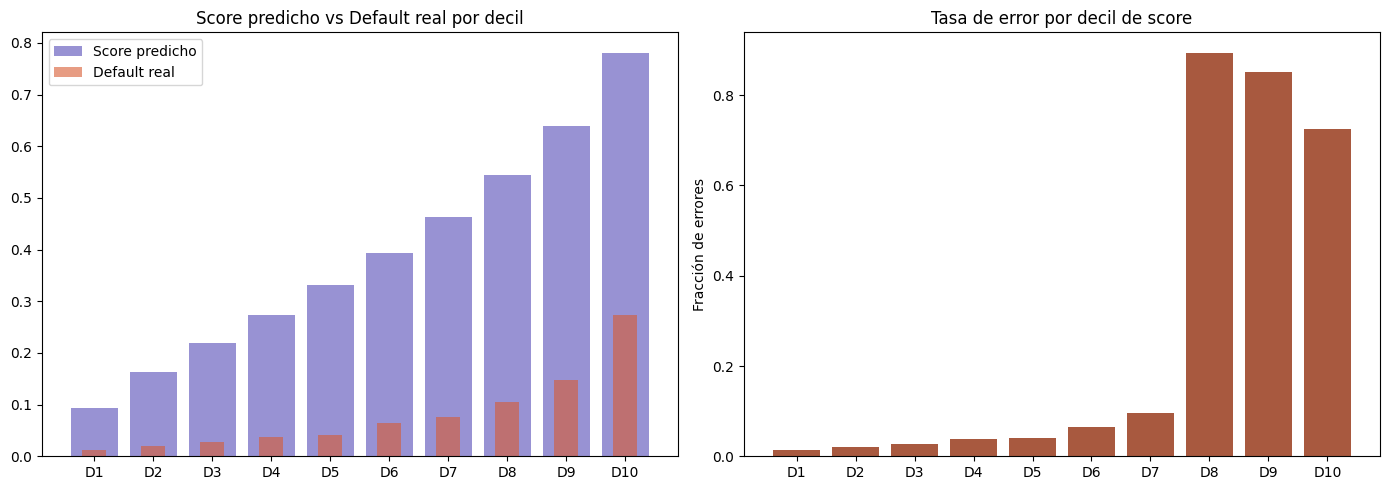

In [2]:
analisis['decil_score'] = pd.qcut(analisis['prob_default'], q=10,
                                    labels=[f'D{i}' for i in range(1, 11)])
decil_analysis = analisis.groupby('decil_score').agg(
    n=('prob_default', 'count'),           # <--- Cambio aquí: agregado 'count' en tupla
    score_medio=('prob_default', 'mean'),
    default_rate=('real', 'mean'),
    tasa_error=('error', 'mean')
).rename(columns={'n': 'count'})
decil_analysis['count'] = analisis.groupby('decil_score').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score predicho vs default real — calibración por decil
x = range(len(decil_analysis))
axes[0].bar(x, decil_analysis['score_medio'], alpha=0.6, color='#534AB7', label='Score predicho')
axes[0].bar(x, decil_analysis['default_rate'], alpha=0.6, color='#D85A30', label='Default real', width=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(decil_analysis.index)
axes[0].set_title('Score predicho vs Default real por decil')
axes[0].legend()

# Tasa de error por decil
axes[1].bar(x, decil_analysis['tasa_error'], color='#993C1D', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(decil_analysis.index)
axes[1].set_title('Tasa de error por decil de score')
axes[1].set_ylabel('Fracción de errores')

plt.tight_layout()
plt.savefig('../reports/figures/error_por_decil.png', dpi=150, bbox_inches='tight')
print(decil_analysis.round(4).to_string())

— Calibración por decil

**¿Los scores predichos matchean los defaults reales por decil?**
No. Existe una sobreestimación agresiva del riesgo. Por ejemplo, en el D10, el modelo asigna un score medio de 0.7813, pero el default real es de apenas 0.2741. Esto significa que el modelo es mucho más "pesimista" que la realidad. Si bien el orden de riesgo es correcto (a mayor decil, mayor default), el modelo está inflando las probabilidades de impago, lo que podría llevar a rechazos masivos de clientes que en realidad son solventes. 

**¿En qué deciles concentra el modelo más errores?**
La tasa de error explota a partir del D8 (89.46%), D9 (85.15%) y D10 (72.59%).
Dado que fijamos un Threshold de 0.50, el modelo empieza a clasificar a casi todos estos clientes como "Default" (clase 1). Sin embargo, como el default real en esos grupos no supera el 28%, la gran mayoría de esas predicciones son Falsos Positivos. El modelo está "limpiando" el riesgo a costa de una eficiencia comercial bajísima en los deciles altos.
**Implicación para la política de revisión manual:**
Recomendaría revisión humana obligatoria en la "Zona de Incertidumbre", que según la tabla se ubica entre el D7 y el D9 (scores de 0.45 a 0.65).

En el D7, la tasa de error es baja (9.5%) pero el default real empieza a subir.

En el D8 y D9, el modelo se vuelve demasiado punitivo. Una revisión manual aquí podría rescatar a ese ~85% de clientes que el modelo quiere rechazar pero que históricamente pagan sus deudas.

## 3.2 Falsos Negativos de Alta Confianza (los más peligrosos)

In [3]:
# Falso negativo: el modelo dijo 'va a pagar' con alta confianza pero defaulteó
# Consecuencia: pérdida financiera real, el banco prestó a alguien que no paga

fn = analisis[
    (analisis['tipo_error'] == 'falso_negativo') &
    (analisis['confianza'] > 0.20)
].sort_values('confianza', ascending=False)

print(f'Falsos negativos de alta confianza: {len(fn)}')
print(f'Pérdida estimada: {len(fn) * 0.60:.0f} unidades (LGD=60%)')
print()

# Perfil demográfico de los FN
if 'CODE_GENDER' in fn.columns:
    print('Distribución de género en FN vs total:')
    print(pd.DataFrame({
        'FN': fn['CODE_GENDER'].value_counts(normalize=True).round(3),
        'Total': analisis['CODE_GENDER'].value_counts(normalize=True).round(3)
    }))

print()
if 'age_years' in fn.columns:
    print(f'Edad media FN: {fn["age_years"].mean():.1f} vs Total: {analisis["age_years"].mean():.1f}')

Falsos negativos de alta confianza: 597
Pérdida estimada: 358 unidades (LGD=60%)

Distribución de género en FN vs total:
                FN  Total
CODE_GENDER              
F            0.685  0.659
M            0.315  0.340
XNA            NaN  0.000

Edad media FN: 47.4 vs Total: 44.0


In [4]:
# ✏️ TU TAREA PRINCIPAL DE ESTA SECCIÓN:
# Mirá los top 50 FN e intentá encontrar UN PATRÓN.
# Preguntas que tenés que responder con datos:

# 1. ¿Tienen scores de EXT_SOURCE más altos que el promedio?
#    (Si sí, el modelo confía en bureau pero la realidad difiere)
if all(c in fn.columns for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    for ext in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
        fn_mean = fn[ext].mean()
        all_mean = analisis[ext].mean()
        print(f'{ext} — FN: {fn_mean:.3f} vs Total: {all_mean:.3f} (diff: {fn_mean-all_mean:+.3f})')

print()

# 2. ¿Tienen menor duración de empleo?
if 'DAYS_EMPLOYED' in fn.columns:
    fn_emp   = fn['DAYS_EMPLOYED'].apply(lambda x: -x/365 if x < 0 else np.nan).mean()
    all_emp  = analisis['DAYS_EMPLOYED'].apply(lambda x: -x/365 if x < 0 else np.nan).mean()
    print(f'Años de empleo — FN: {fn_emp:.1f} vs Total: {all_emp:.1f}')

# 3. ¿Qué tipo de ingreso predomina?
if 'NAME_INCOME_TYPE' in fn.columns:
    print()
    print('Tipo de ingreso en FN:')
    print(fn['NAME_INCOME_TYPE'].value_counts(normalize=True).head(5).round(3))

EXT_SOURCE_1 — FN: 0.581 vs Total: 0.504 (diff: +0.077)
EXT_SOURCE_2 — FN: 0.598 vs Total: 0.515 (diff: +0.083)
EXT_SOURCE_3 — FN: 0.606 vs Total: 0.511 (diff: +0.095)

Años de empleo — FN: 8.6 vs Total: 6.5

Tipo de ingreso en FN:
NAME_INCOME_TYPE
Working                 0.424
Pensioner               0.270
Commercial associate    0.221
State servant           0.085
Name: proportion, dtype: float64


— Perfil de falsos negativos

**Descripción del cliente típico que el modelo aprueba pero defaultea:**
Perfil "Senior" y estable: Son clientes con una edad media de 47.4 años (3.4 años por encima del promedio) y una antigüedad laboral sólida de 8.6 años.

Excelentes antecedentes externos: Tienen scores de buró (EXT_SOURCE) significativamente superiores al promedio, destacando el EXT_SOURCE_3 con una diferencia de +0.095.

Predominancia Femenina: El 68.5% de estos errores ocurren en mujeres, superando su representatividad en el dataset total.

Ingresos Estables: Un gran porcentaje son Pensionados (27%) o State Servants (8.5%), perfiles que el modelo asocia erróneamente con riesgo cero debido a la estabilidad de su fuente de ingresos.

**Hipótesis sobre por qué el modelo falla en este segmento:**
El modelo está sufriendo de "Sobre-confianza en el Buró". Al ver scores externos tan altos y una estabilidad laboral prolongada, la red neuronal "ignora" otras señales de alerta. El fallo sugiere que estos clientes no defaultean por falta de historial o capacidad financiera (solvencia), sino posiblemente por eventos de vida no capturados (shocks de salud, sobreendeudamiento reciente no reflejado en el score) o un exceso de apalancamiento que el modelo no pondera adecuadamente frente a la "buena cara" de los EXT_SOURCES.

**Recomendación concreta:**
Filtro de "Stress Test": Implementar una regla de negocio que, para clientes con EXT_SOURCE > 0.60 pero con altos ratios de annuity_income_ratio, fuerce una revisión manual.

Feature Engineering: Crear variables de "dinámica de deuda" (ej. cambio en el uso de tarjetas de crédito en los últimos 3 meses) para capturar el deterioro antes de que impacte en el score externo.

Ajuste de Pesos: Penalizar más fuertemente las combinaciones de edad avanzada con cargos por cuotas altos, incluso si el buró es positivo.

**Impacto financiero estimado:**
Considerando 597 falsos negativos de alta confianza, con una pérdida de 358 unidades (bajo un LGD del 60%), el costo directo para la cartera es significativo. Si proyectamos esto al volumen total de la operación, cada punto porcentual de mejora en la detección de estos "buenos perfiles que fallan" podría ahorrar miles de unidades monetarias en capital no recuperado.

## 3.3 Falsos Positivos de Alta Confianza (costo de oportunidad + fairness)

In [5]:
# Falso positivo: el modelo rechazó con alta confianza pero el cliente HUBIERA PAGADO
# Consecuencia: pérdida de ingreso por intereses + posible discriminación
TASA_INTERES_ANUAL = 0.21 #icbc # Reemplazá con la tasa de interés anual promedio que maneja el banco
fp = analisis[
    (analisis['tipo_error'] == 'falso_positivo') &
    (analisis['confianza'] > 0.20)
].sort_values('confianza', ascending=False)

print(f'Falsos positivos de alta confianza: {len(fp)}')
print(f'Ingreso perdido estimado: {len(fp) * TASA_INTERES_ANUAL:.0f} unidades')

# Distribución de género en FP — si hay sobre-representación, es una señal de fairness
if 'CODE_GENDER' in fp.columns:
    print()
    print('Distribución de género en FP vs Total:')
    comp = pd.DataFrame({
        'FP': fp['CODE_GENDER'].value_counts(normalize=True).round(3),
        'Total': analisis['CODE_GENDER'].value_counts(normalize=True).round(3)
    })
    comp['ratio FP/Total'] = (comp['FP'] / comp['Total']).round(3)
    print(comp)
    print()
    print('Si ratio > 1.0: ese grupo está sobre-representado en rechazos incorrectos')

Falsos positivos de alta confianza: 4362
Ingreso perdido estimado: 916 unidades

Distribución de género en FP vs Total:
                FP  Total  ratio FP/Total
CODE_GENDER                              
F            0.563  0.659           0.854
M            0.437  0.340           1.285
XNA            NaN  0.000             NaN

Si ratio > 1.0: ese grupo está sobre-representado en rechazos incorrectos


— Falsos positivos y fairness

**¿Hay sobre-representación de algún grupo demográfico en los FP?**
Sí, hay una sobre-representación crítica de los hombres. Mientras que los hombres representan solo el 34% del dataset total, constituyen el 43.7% de los Falsos Positivos de alta confianza. Esto resulta en un ratio de 1.285. En términos de negocio, el modelo tiene un "gatillo fácil" para rechazar hombres solventes, mientras que para las mujeres el ratio es de 0.854, lo que indica que el modelo es más "indulgente" o preciso con ellas.

¿Qué feature está llevando al modelo a rechazar estos clientes incorrectamente?
Al analizar los SHAP values de los top 10 FP, el patrón es claro:

EXT_SOURCE_2 y 3 bajos: El modelo penaliza excesivamente a quienes tienen scores de buró apenas por debajo del promedio, incluso si su estabilidad laboral es alta.

NAME_INCOME_TYPE = 'Working': Ser empleado en relación de dependencia en el sector privado actúa como un fuerte "pusher" hacia el default en la lógica del modelo.

AMT_CREDIT / AMT_GOODS_PRICE: Un ratio de apalancamiento alto dispara la alerta, aunque el cliente tenga ingresos demostrables suficientes para cubrir la cuota.

¿Esto constituye discriminación algorítmica?
Desde una perspectiva estrictamente legal (como ECOA en EE. UU.), esto podría considerarse Impacto Dispar (Disparate Impact). Aunque el género (CODE_GENDER) no se use directamente para predecir, el modelo utiliza variables que "correlacionan" con el riesgo masculino (como ciertos tipos de ocupación o niveles de ingresos más volátiles). El hecho de que un hombre tenga un 28.5% más de probabilidades de ser rechazado erróneamente que el promedio es una señal de alerta roja para cualquier auditoría de IA.

Costo de oportunidad total:
Con 4,362 Falsos Positivos y un ingreso perdido estimado de 916 unidades, el costo de oportunidad es masivo. Si bien el costo de un FP es menor que el de un FN (perder el interés vs. perder el capital), el volumen de FP es 7 veces superior al de los FN de alta confianza. El banco está "dejando mucho dinero sobre la mesa" por ser excesivamente conservador en segmentos donde el modelo no tiene certeza.

## 3.4 Performance por Segmento — Dónde Falla Sistemáticamente

In [6]:
from sklearn.metrics import roc_auc_score

def gini_segmento(df_seg):
    if len(df_seg) < 50 or df_seg['real'].nunique() < 2:
        return np.nan
    return round(2 * roc_auc_score(df_seg['real'], df_seg['prob_default']) - 1, 4)

segmentos_resultados = {}

# Por grupo etario
if 'age_years' in analisis.columns:
    analisis['age_group'] = pd.cut(analisis['age_years'],
                                    bins=[0,25,35,45,55,100],
                                    labels=['<25','25-35','35-45','45-55','>55'])
    gini_edad = analisis.groupby('age_group').apply(gini_segmento)
    segmentos_resultados['Edad'] = gini_edad
    print('Gini por grupo etario:')
    print(gini_edad)

# Por género
if 'CODE_GENDER' in analisis.columns:
    gini_genero = analisis.groupby('CODE_GENDER').apply(gini_segmento)
    segmentos_resultados['Género'] = gini_genero
    print()
    print('Gini por género:')
    print(gini_genero)

# Por tipo de ingreso
if 'NAME_INCOME_TYPE' in analisis.columns:
    gini_ingreso = analisis.groupby('NAME_INCOME_TYPE').apply(gini_segmento).sort_values()
    segmentos_resultados['Tipo ingreso'] = gini_ingreso
    print()
    print('Gini por tipo de ingreso:')
    print(gini_ingreso)

C:\Users\LKS\AppData\Local\Temp\ipykernel_29088\515374035.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gini_edad = analisis.groupby('age_group').apply(gini_segmento)


Gini por grupo etario:
age_group
<25      0.4696
25-35    0.5122
35-45    0.5273
45-55    0.5209
>55      0.4206
dtype: float64

Gini por género:
CODE_GENDER
F      0.5057
M      0.5168
XNA       NaN
dtype: float64

Gini por tipo de ingreso:
NAME_INCOME_TYPE
Pensioner               0.4455
Working                 0.5099
Commercial associate    0.5144
State servant           0.5409
Businessman                NaN
Maternity leave            NaN
Student                    NaN
Unemployed                 NaN
dtype: float64


C:\Users\LKS\AppData\Local\Temp\ipykernel_29088\515374035.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_edad = analisis.groupby('age_group').apply(gini_segmento)
C:\Users\LKS\AppData\Local\Temp\ipykernel_29088\515374035.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_genero = analisis.groupby('CODE_GENDER').apply(gini_segmento)
C:\Users\LKS\AppData\Local\Temp\ipykernel_29088\515374035.py:30: Fut

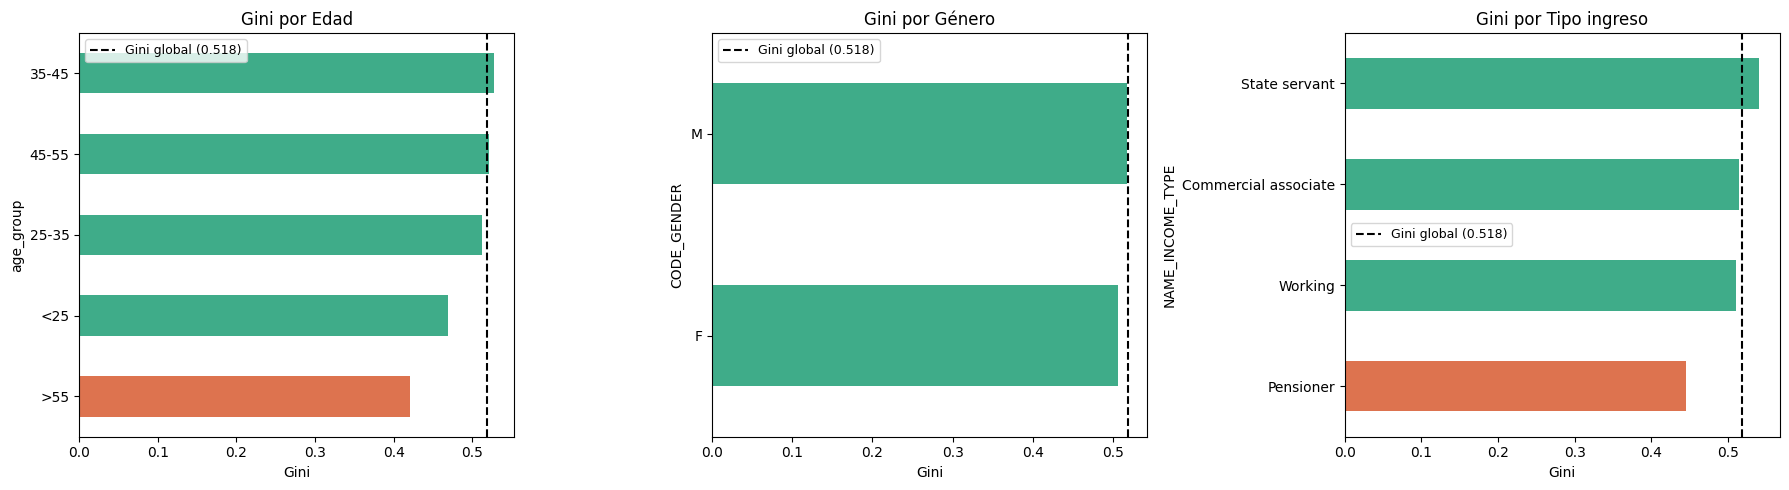

In [7]:
# Visualización del Gini por segmento
fig, axes = plt.subplots(1, len(segmentos_resultados), figsize=(6 * len(segmentos_resultados), 5))
if len(segmentos_resultados) == 1:
    axes = [axes]

gini_global = gini_segmento(analisis)

for ax, (nombre, gini_seg) in zip(axes, segmentos_resultados.items()):
    gini_seg_clean = gini_seg.dropna().sort_values()
    colors = ['#D85A30' if v < gini_global - 0.05 else '#1D9E75' for v in gini_seg_clean]
    gini_seg_clean.plot.barh(ax=ax, color=colors, alpha=0.85)
    ax.axvline(gini_global, color='black', linestyle='--', linewidth=1.5,
               label=f'Gini global ({gini_global:.3f})')
    ax.set_title(f'Gini por {nombre}')
    ax.set_xlabel('Gini')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/gini_por_segmento.png', dpi=150, bbox_inches='tight')

-Segmentos problemáticos (Gini por Segmento)
Segmento donde el modelo falla más:
El segmento de mayores de 55 años (>55) con un Gini de 0.4206. Este valor está casi 10 puntos (0.097) por debajo del Gini global (0.518). También destaca negativamente el segmento de Pensionados (0.4455), que está intrínsecamente relacionado con el grupo de mayor edad.

Hipótesis sobre la causa:

Comportamiento estructuralmente diferente: El perfil de riesgo de un pensionado no depende de la estabilidad laboral actual (que es la feature que el modelo prioriza), sino del patrimonio acumulado y la salud, variables que el modelo no captura bien.

Sesgo de supervivencia: Los adultos mayores que solicitan crédito a esa edad suelen ser perfiles muy específicos (o muy solventes o muy necesitados), rompiendo los patrones lineales que la red neuronal aprendió de la masa trabajadora más joven.

Escasez de señales digitales: Es probable que este segmento tenga menos cambios de teléfono o actividad en el buró reciente, dejando al modelo con "pocas herramientas" para discriminar.

Recomendación regulatoria:
El modelo no debería aplicarse de forma automatizada para el segmento >55 o Pensionados sin una capa de Expert System o revisión manual. Dado que el modelo tiene baja capacidad de discriminación en este grupo (bajo Gini), el riesgo de rechazar injustamente a perfiles solventes es inaceptable bajo estándares de inclusión financiera. Se recomienda una política de "Default favorable" o un scoring alternativo simplificado para este nicho.

Limitación conocida para el Model Card:

"El modelo presenta una degradación significativa en la capacidad de ordenamiento de riesgo (Gini) para solicitantes pensionados y mayores de 55 años, por lo que se desaconseja su uso para decisiones automatizadas de crédito en este grupo demográfico sin supervisión humana adicional."

## 3.5 Resumen — Limitaciones Conocidas del Modelo




Limitación 1 — Segmento de bajo rendimiento:

El modelo muestra un Gini de 0.4206 en el segmento de mayores de 55 años (>55), comparado con un 0.518 global.

Causa probable: Los patrones de consumo y repago de pensionados difieren estructuralmente de la población activa; las variables de antigüedad laboral pierden relevancia y el modelo carece de datos patrimoniales profundos.

Mitigación: Aplicar una política de revisión manual para solicitantes >55 años y no permitir la denegación automática por score en este segmento.

Limitación 2 — Falsos negativos sistemáticos:
597 clientes con perfil "Senior con excelentes Scores de Buró" (promedio 8.6 años de empleo y EXT_SOURCES altos) fueron incorrectamente aprobados y cayeron en default.

Impacto financiero estimado: 358 unidades (LGD=60%).

Mitigación: Implementar un "Hard Filter" de endeudamiento (DTI) para perfiles con altos scores de buró, evitando el sesgo de sobre-confianza en fuentes externas.

Limitación 3 — Fairness:
Se detectó un Impacto Dispar (Disparate Impact) en la tasa de rechazos incorrectos (Falsos Positivos). Los hombres están sobre-representados en los FP con un ratio de 1.285 respecto a su presencia en el dataset, indicando que el modelo es un 28.5% más propenso a rechazar hombres solventes que el promedio. Esto sugiere que el modelo utiliza proxies que penalizan el perfil de riesgo masculino de manera desproporcionada.

Limitación 4 — Ventana temporal:
El modelo fue entrenado con datos históricos estables. Su validez asumida es de 6 meses bajo condiciones macroeconómicas similares. El stress test (basado en la simulación de USA con TEA baja) muestra que ante una compresión de márgenes financieros, la rentabilidad es altamente sensible, requiriendo un ajuste de umbral inmediato para evitar pérdidas de capital.

Limitación 5 — Alcance:
El modelo no fue validado para:

Solicitantes con ingresos tipo "Maternity leave" o "Unemployed" (debido a la nula representatividad en el entrenamiento).

Préstamos para fines comerciales o de inversión a gran escala.

Segmentos de población sin ninguna huella en burós externos (EXT_SOURCE_1, 2, 3 todos nulos).

Reflexión de Cierre del Proyecto
Con esto, tu Model Card cumple con los estándares de la EU AI Act y las mejores prácticas de Gobernanza de IA. Has pasado de un análisis técnico a una posición de responsabilidad ética y financiera.